In [1]:
import pandas as pd
import xarray as xr
profile_path = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter0/PROF_eq/TAO_WO_2012_ADCP_model.nc'
ds_adcp = xr.open_dataset(profile_path)

# Combine date and time into a datetime array
dates = ds_adcp['prof_YYYYMMDD'].values.astype(int)
times = ds_adcp['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_adcp = ds_adcp.assign_coords(time=('iPROF', datetimes))
# ds_adcp = ds_adcp.swap_dims({'iPROF': 'time'})
ds_adcp = ds_adcp.assign_coords(depth=('iDEPTH', ds_adcp['prof_depth'].values*-1))
# ds_adcp = ds_adcp.swap_dims({'iDEPTH': 'depth'})
ds_adcp = ds_adcp.assign_coords(lat=('iPROF', ds_adcp['prof_lat'].values))
ds_adcp = ds_adcp.assign_coords(lon=('iPROF', ds_adcp['prof_lon'].values))
# group profiles by longitude (these are all equatorial TAO moorings)
adcp_by_lon_iter0 = ds_adcp.groupby('lon')

In [2]:
profile_path = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/PROF_eq/TAO_WO_2012_ADCP_model.nc'
ds_adcp = xr.open_dataset(profile_path)

# Combine date and time into a datetime array
dates = ds_adcp['prof_YYYYMMDD'].values.astype(int)
times = ds_adcp['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_adcp = ds_adcp.assign_coords(time=('iPROF', datetimes))
# ds_adcp = ds_adcp.swap_dims({'iPROF': 'time'})
ds_adcp = ds_adcp.assign_coords(depth=('iDEPTH', ds_adcp['prof_depth'].values*-1))
# ds_adcp = ds_adcp.swap_dims({'iDEPTH': 'depth'})
ds_adcp = ds_adcp.assign_coords(lat=('iPROF', ds_adcp['prof_lat'].values))
ds_adcp = ds_adcp.assign_coords(lon=('iPROF', ds_adcp['prof_lon'].values))
# group profiles by longitude (these are all equatorial TAO moorings)
adcp_by_lon_iter22 = ds_adcp.groupby('lon')

In [3]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from matplotlib.colors import TwoSlopeNorm
import cmocean.cm as cmo
warnings.filterwarnings("ignore")
plt.rcParams['font.size'] = 13


In [4]:
def slice_by_time_keep_lon(group, start_time):
    """
    Slice a group (Dataset) by time without overwriting lon.
    
    group: xarray Dataset for a single lon
    start_time: np.datetime64 or string
    """
    # Boolean mask along the profile dimension (iPROF)
    mask = group.time >= np.datetime64(start_time)
    
    # Select the profiles, keep all coordinates intact
    return group.isel(iPROF=mask)

In [5]:
# Initialize the values array
uncertainty = np.zeros_like(adcp_by_lon_iter0[-140].depth, dtype=float)

# Region 1: Above 25 m (depth > -25 since depths are negative)
uncertainty[adcp_by_lon_iter0[-140].depth > -25] = 0.2

# Region 2: Between 25m and 150m (depth between -150 and -25)
mask = (adcp_by_lon_iter0[-140].depth <= -25) & (adcp_by_lon_iter0[-140].depth >= -150)
# Linear interpolation from 0.2 at -25 to 0.07 at -150
uncertainty[mask] = 0.2 + (0.08 - 0.2) * (adcp_by_lon_iter0[-140].depth[mask] + 25) / (-150 + 25)

# Region 3: Below 150m (depth < -150)
uncertainty[adcp_by_lon_iter0[-140].depth < -150] = 0.08

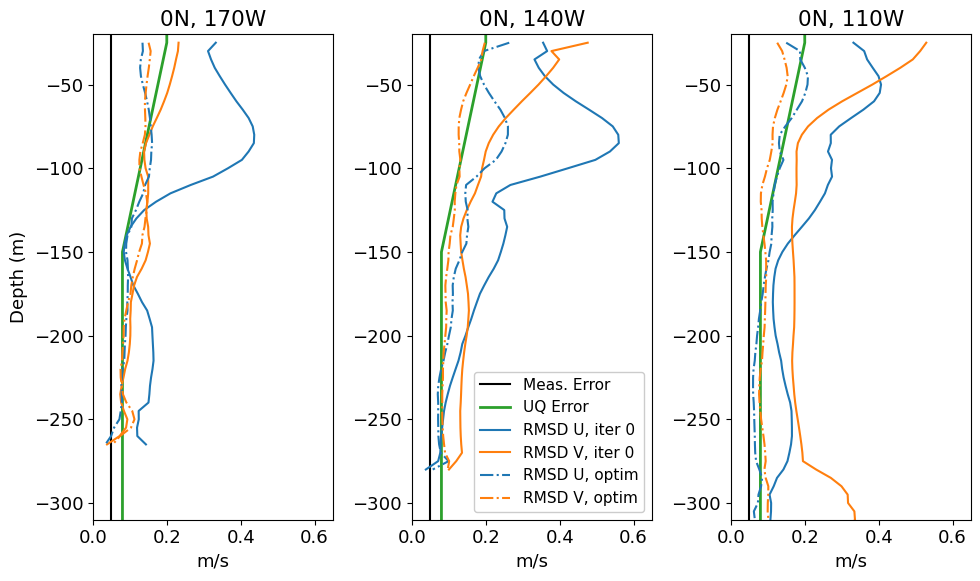

In [8]:
fig, ax = plt.subplots(figsize=(10,6),ncols=3)

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon_iter0[-170.0], "2012-09-01")
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
rms_diffU_iter0 = np.sqrt((diffU**2).mean(axis=0))
rms_diffV_iter0 = np.sqrt((diffV**2).mean(axis=0))

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon_iter22[-170.0], "2012-09-01")
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
rms_diffU_iter22 = np.sqrt((diffU**2).mean(axis=0))
rms_diffV_iter22 = np.sqrt((diffV**2).mean(axis=0))

ax[0].axvline(0.05, color='k', linewidth=1.5,label='Meas. Error')
ax[0].plot(uncertainty,adcp_by_lon_subset.depth,label='UQ Error',lw=2.0,color='tab:green')
ax[0].plot(rms_diffU_iter0,adcp_by_lon_subset.depth,label='RMSD U, iter 0',color='tab:blue')
ax[0].plot(rms_diffV_iter0,adcp_by_lon_subset.depth,label='RMSD V, iter 0',color='tab:orange')
ax[0].plot(rms_diffU_iter22,adcp_by_lon_subset.depth,label='RMSD U, optim',color='tab:blue',linestyle='-.')
ax[0].plot(rms_diffV_iter22,adcp_by_lon_subset.depth,label='RMSD V, optim',color='tab:orange',linestyle='-.')
ax[0].set_xlim(0.0,0.65)
ax[0].set_xlabel('m/s')
ax[0].set_ylim(-310,-20)
ax[0].set_ylabel('Depth (m)')
# ax[0].legend(loc='lower right',fontsize=12)
ax[0].set_title('0N, 170W')

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon_iter0[-140.0], "2012-09-01")
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
rms_diffU_iter0 = np.sqrt((diffU**2).mean(axis=0))
rms_diffV_iter0 = np.sqrt((diffV**2).mean(axis=0))

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon_iter22[-140.0], "2012-09-01")
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
rms_diffU_iter22 = np.sqrt((diffU**2).mean(axis=0))
rms_diffV_iter22 = np.sqrt((diffV**2).mean(axis=0))

ax[1].axvline(0.05, color='k', linewidth=1.5,label='Meas. Error')
ax[1].plot(uncertainty,adcp_by_lon_subset.depth,label='UQ Error',lw=2.0,color='tab:green')
ax[1].plot(rms_diffU_iter0,adcp_by_lon_subset.depth,label='RMSD U, iter 0',color='tab:blue')
ax[1].plot(rms_diffV_iter0,adcp_by_lon_subset.depth,label='RMSD V, iter 0',color='tab:orange')
ax[1].plot(rms_diffU_iter22,adcp_by_lon_subset.depth,label='RMSD U, optim',color='tab:blue',linestyle='-.')
ax[1].plot(rms_diffV_iter22,adcp_by_lon_subset.depth,label='RMSD V, optim',color='tab:orange',linestyle='-.')
ax[1].set_xlim(0.0,0.65)
ax[1].set_ylim(-310,-20)
ax[1].legend(loc='lower right',fontsize=11, framealpha=1)
ax[1].set_xlabel('m/s')
ax[1].set_title('0N, 140W')

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon_iter0[-110.0], "2012-09-01")
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
rms_diffU_iter0 = np.sqrt((diffU**2).mean(axis=0))
rms_diffV_iter0 = np.sqrt((diffV**2).mean(axis=0))

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon_iter22[-110.0], "2012-09-01")
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
rms_diffU_iter22 = np.sqrt((diffU**2).mean(axis=0))
rms_diffV_iter22 = np.sqrt((diffV**2).mean(axis=0))

ax[2].axvline(0.05, color='k', linewidth=1.5,label='Meas. Error')
ax[2].plot(uncertainty,adcp_by_lon_subset.depth,label='UQ Error',lw=2.0,color='tab:green')
ax[2].plot(rms_diffU_iter0,adcp_by_lon_subset.depth,label='RMSD U, iter 0',color='tab:blue')
ax[2].plot(rms_diffV_iter0,adcp_by_lon_subset.depth,label='RMSD V, iter 0',color='tab:orange')
ax[2].plot(rms_diffU_iter22,adcp_by_lon_subset.depth,label='RMSD U, optim',color='tab:blue',linestyle='-.')
ax[2].plot(rms_diffV_iter22,adcp_by_lon_subset.depth,label='RMSD V, optim',color='tab:orange',linestyle='-.')
ax[2].set_xlim(0.0,0.65)
ax[2].set_ylim(-310,-20)
ax[2].set_xlabel('m/s')
ax[2].set_title('0N, 110W')
plt.tight_layout()
plt.savefig('/home/edavenport/analysis/vel-assim-manuscript/sep2012_test_UQ/rmsd_uq.png',dpi=300)